In [40]:
# --- LIBRERÍA  ---
#El sistema fue diseñado para imágenes cenitales con contraste suficiente entre objeto y fondo.
#Se empleó umbralización global con Otsu, por lo que el desempeño es óptimo cuando existe separación de intensidad.
#En escenarios con iluminación variable o colores similares, podría mejorarse usando umbralización adaptativa o segmentación basada en color.

codigo_libreria = """
import cv2
import numpy as np

class ContadorObjetos:

    def __init__(self):
        pass


    # PREPROCESAMIENTO
    def mejorar_imagen(self,imagen):

        imagen_gris = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)

        # Suavizar ruido
        imagen_suave = cv2.GaussianBlur(imagen_gris,(5,5),0)

        # Mejorar contraste
        imagen_mejorada = (cv2.convertScaleAbs(imagen_suave,alpha=1.15,beta=5))

        return imagen_mejorada

    # SEGMENTACIÓN
    def separar_objetos(self,imagen_gris):

        # Threshold automático
        _, mascara = cv2.threshold(imagen_gris,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        kernel = np.ones((3,3),np.uint8)

        # Limpiar ruido
        mascara = cv2.morphologyEx(mascara,cv2.MORPH_OPEN,kernel,iterations=1)

        # Cerrar huecos
        mascara = cv2.morphologyEx(mascara,cv2.MORPH_CLOSE,kernel,iterations=2)

        return mascara

    # BORDES
    def sacar_bordes(self,imagen_gris):

        bordes = cv2.Canny(imagen_gris,50,150)

        return bordes

    # ESQUINAS
    def sacar_esquinas(self,imagen_gris,mascara):

        solo_objetos = (cv2.bitwise_and(imagen_gris,imagen_gris,mask=mascara))

        esquinas = cv2.cornerHarris(np.float32(solo_objetos),2,3,0.04)

        return esquinas

    # CONTEO
    def contar_objetos(self,mascara,imagen_original):

        imagen_resultado = (imagen_original.copy())

        datos_objetos = []

        # Watershed para separar objetos pegados
        kernel = np.ones((3,3),np.uint8)

        fondo_seguro = cv2.dilate(mascara,kernel,iterations=2)

        distancia = (cv2.distanceTransform(mascara,cv2.DIST_L2,5))

        _, primer_plano = (cv2.threshold(distancia,0.25 * distancia.max(),255,0))

        primer_plano = np.uint8(primer_plano)

        zona_desconocida = cv2.subtract(fondo_seguro,primer_plano)

        _, marcadores = (cv2.connectedComponents(primer_plano))

        marcadores = (marcadores + 1)

        marcadores[zona_desconocida == 255] = 0

        marcadores = cv2.watershed(imagen_original,marcadores)

        numero_objeto = 1

        for etiqueta in np.unique(marcadores):

            if etiqueta <= 1:
                continue

            mascara_objeto = np.zeros(mascara.shape,dtype="uint8")

            mascara_objeto[marcadores == etiqueta] = 255

            contornos, _ = (cv2.findContours(mascara_objeto,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE))

            if len(contornos) == 0:
                continue

            contorno = max(contornos,key=cv2.contourArea)

            area = cv2.contourArea(contorno)

            # eliminar ruido
            if area < 300:
                continue

            x, y, ancho, alto = (cv2.boundingRect(contorno))

            perimetro = (cv2.arcLength(contorno,True))

            momentos = (cv2.moments(contorno))

            if momentos["m00"] != 0:

                centro_x = int(momentos["m10"]/momentos["m00"])

                centro_y = int(momentos["m01"]/momentos["m00"])

            else:

                centro_x = 0
                centro_y = 0

            cv2.drawContours(imagen_resultado,[contorno],-1,(0,255,0),2)

            cv2.circle(imagen_resultado,(centro_x,centro_y),5,(255,0,0),-1)

            cv2.putText(imagen_resultado,f"#{numero_objeto}",(x, y - 10),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

            datos_objetos.append({

                "numero":numero_objeto,
                "area":area,
                "perimetro":perimetro,
                "centro":(centro_x,centro_y)

            })

            numero_objeto += 1

        return (imagen_resultado,datos_objetos)
"""

with open("vision_lib.py","w",encoding="utf-8") as archivo:

    archivo.write(codigo_libreria)

print("Librería guardada correctamente")

Librería guardada correctamente


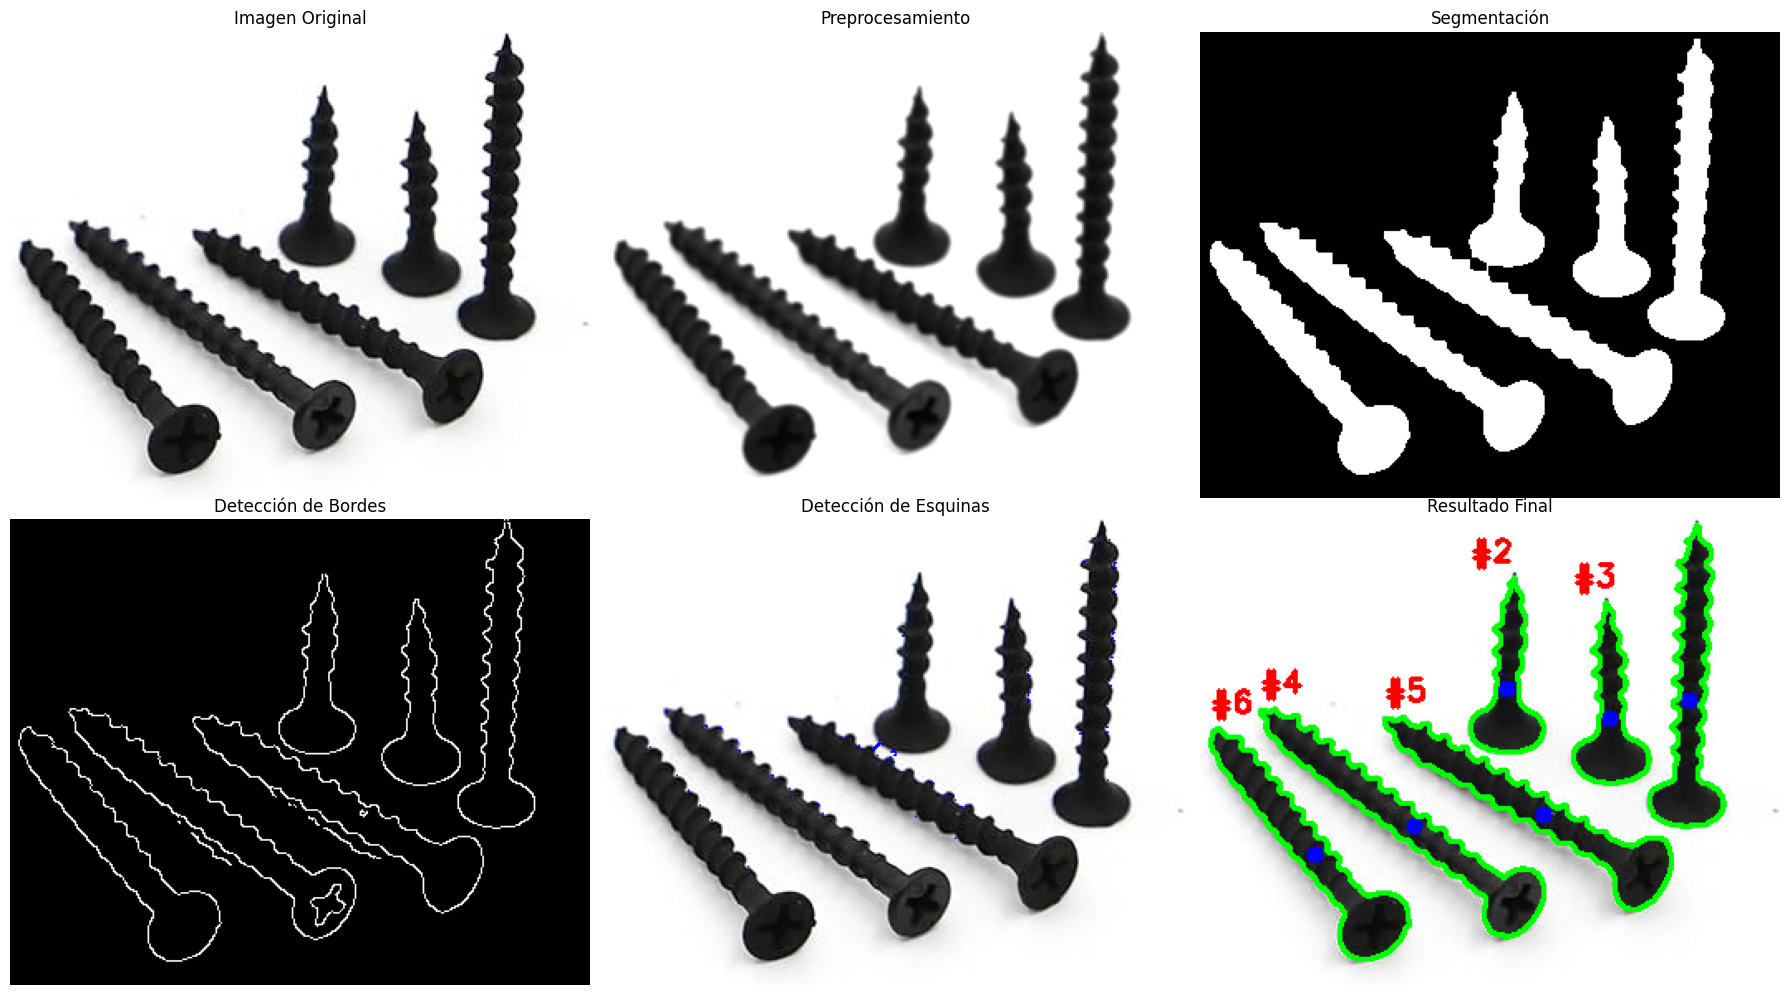

----------------------------------------
RESULTADOS
----------------------------------------
Objetos encontrados: 6
----------------------------------------
Objeto #1
Área: 3307.50
Perímetro: 496.80
Centro: (295, 109)
--------------------
Objeto #2
Área: 1975.50
Perímetro: 283.52
Centro: (185, 102)
--------------------
Objeto #3
Área: 2059.50
Perímetro: 301.32
Centro: (247, 120)
--------------------
Objeto #4
Área: 4079.00
Perímetro: 539.33
Centro: (129, 185)
--------------------
Objeto #5
Área: 3899.00
Perímetro: 513.39
Centro: (207, 178)
--------------------
Objeto #6
Área: 3695.00
Perímetro: 440.42
Centro: (69, 202)
--------------------


In [44]:
# --- PRUEBA LIBRERIA ---

import matplotlib.pyplot as plt
from vision_lib import ContadorObjetos
import cv2
import os

nombre_imagen = "mas2.jpg"

if not os.path.exists(nombre_imagen):

    print("No se encontró la imagen")

else:

    foto = cv2.imread(nombre_imagen)

    contador = (ContadorObjetos())


    # PREPROCESAMIENTO
    imagen_lista = (contador.mejorar_imagen(foto))

    # SEGMENTACIÓN
    mascara_final = (contador.separar_objetos(imagen_lista))

    # BORDES
    bordes = (contador.sacar_bordes(imagen_lista))

    # ESQUINAS
    esquinas = (contador.sacar_esquinas(imagen_lista,mascara_final))

    imagen_esquinas = (foto.copy())

    limite = (0.05 * esquinas.max())

    imagen_esquinas[esquinas > limite] = [255, 0, 0]


    # CONTEO
    imagen_final, datos = (contador.contar_objetos(mascara_final,foto))

    # MOSTRAR RESULTADOS
    plt.figure(figsize=(18, 10))

    plt.subplot(2,3,1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(foto,cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.title("Preprocesamiento")
    plt.imshow(imagen_lista,cmap="gray")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.title("Segmentación")
    plt.imshow(mascara_final,cmap="gray")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.title("Detección de Bordes")
    plt.imshow(bordes,cmap="gray")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.title("Detección de Esquinas")
    plt.imshow(cv2.cvtColor(imagen_esquinas,cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.title("Resultado Final")
    plt.imshow(cv2.cvtColor(imagen_final,cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()


    # Resultados
    print("-" * 40)
    print("RESULTADOS")
    print("-" * 40)
    print("Objetos encontrados:",len(datos))
    print("-" * 40)

    for objeto in datos:

        print(f"Objeto #{objeto['numero']}")
        print(f"Área: " f"{objeto['area']:.2f}")
        print(f"Perímetro: " f"{objeto['perimetro']:.2f}")
        print(f"Centro: " f"{objeto['centro']}")
        print("-" * 20)